# TimesFM Forecast Demo\n\nForecasting various mathematical functions and comparing predictions against ground truth.

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import timesfm

torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)
print("Model loaded")

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.
Model loaded


In [46]:
# Define test functions
CONTEXT_LEN = 200
HORIZON = 64

def gaussian(t, mu, sigma, amp=1.0):
    return amp * np.exp(-0.5 * ((t - mu) / sigma) ** 2)

functions = {
    # --- Original simple functions ---
    "Sine": lambda t: np.sin(t * 0.3),
    "Linear": lambda t: 0.05 * t + 1,
    "Quadratic": lambda t: 0.001 * t**2,
    "Log Growth": lambda t: np.log1p(t),

    # --- Gaussian combinations ---
    "Gaussian Peaks": lambda t: (
        gaussian(t, 60, 15, 2.0) + gaussian(t, 140, 10, 3.0) + gaussian(t, 220, 20, 1.5)
    ),
    "Gaussian + Sine": lambda t: (
        gaussian(t, 100, 30, 2.0) + gaussian(t, 200, 25, 1.5) + 0.3 * np.sin(t * 0.5)
    ),
    "Gaussian Mixture Oscillation": lambda t: (
        gaussian(t, 80, 20, 1.0) - gaussian(t, 130, 15, 1.5) + gaussian(t, 210, 25, 2.0)
    ),

    # --- Chirps and modulated signals ---
    "Chirp (increasing freq)": lambda t: np.sin(0.01 * t**2 * 0.1),
    "AM Signal": lambda t: (1 + 0.5 * np.sin(t * 0.05)) * np.sin(t * 0.4),
    "FM Signal": lambda t: np.sin(t * 0.3 + 2.0 * np.sin(t * 0.02)),

    # --- Rational and special ---
    "Lorentzian Peaks": lambda t: (
        1.0 / (1 + ((t - 80) / 10)**2) + 1.5 / (1 + ((t - 180) / 15)**2)
        + 0.8 / (1 + ((t - 240) / 8)**2)
    ),
    "Sigmoid Step": lambda t: 1 / (1 + np.exp(-0.1 * (t - 100))) + 1 / (1 + np.exp(-0.1 * (t - 200))),
    "Sinc": lambda t: np.sinc((t - 130) / 20),

    # --- Compositions ---
    "Gaussian Envelope Chirp": lambda t: (
        gaussian(t, 130, 50, 1.0) * np.sin(0.005 * t**2)
    ),
    "Piecewise Polynomial": lambda t: np.piecewise(
        t, [t < 88, (t >= 88) & (t < 176), t >= 176],
        [lambda x: 0.001 * (x - 44)**2,
         lambda x: -0.0005 * (x - 132)**2 + 2,
         lambda x: 0.0003 * (x - 220)**3 / 50 + 1]
    ),
    "Damped Beating": lambda t: np.exp(-0.005 * t) * np.sin(t * 0.3) * np.sin(t * 0.31),
}

t_full = np.arange(CONTEXT_LEN + HORIZON, dtype=float)
series_data = {}
for name, fn in functions.items():
    full = fn(t_full)
    series_data[name] = {
        "context": full[:CONTEXT_LEN],
        "ground_truth": full[CONTEXT_LEN:],
    }
print(f"{len(functions)} functions defined")

16 functions defined


In [47]:
# Run forecasts
names = list(series_data.keys())
contexts = [series_data[n]["context"] for n in names]

point_forecast, quantile_forecast = model.forecast(
    horizon=HORIZON,
    inputs=contexts,
)
print(f"Point forecast shape: {point_forecast.shape}")
print(f"Quantile forecast shape: {quantile_forecast.shape}")

Point forecast shape: (16, 64)
Quantile forecast shape: (16, 64, 10)


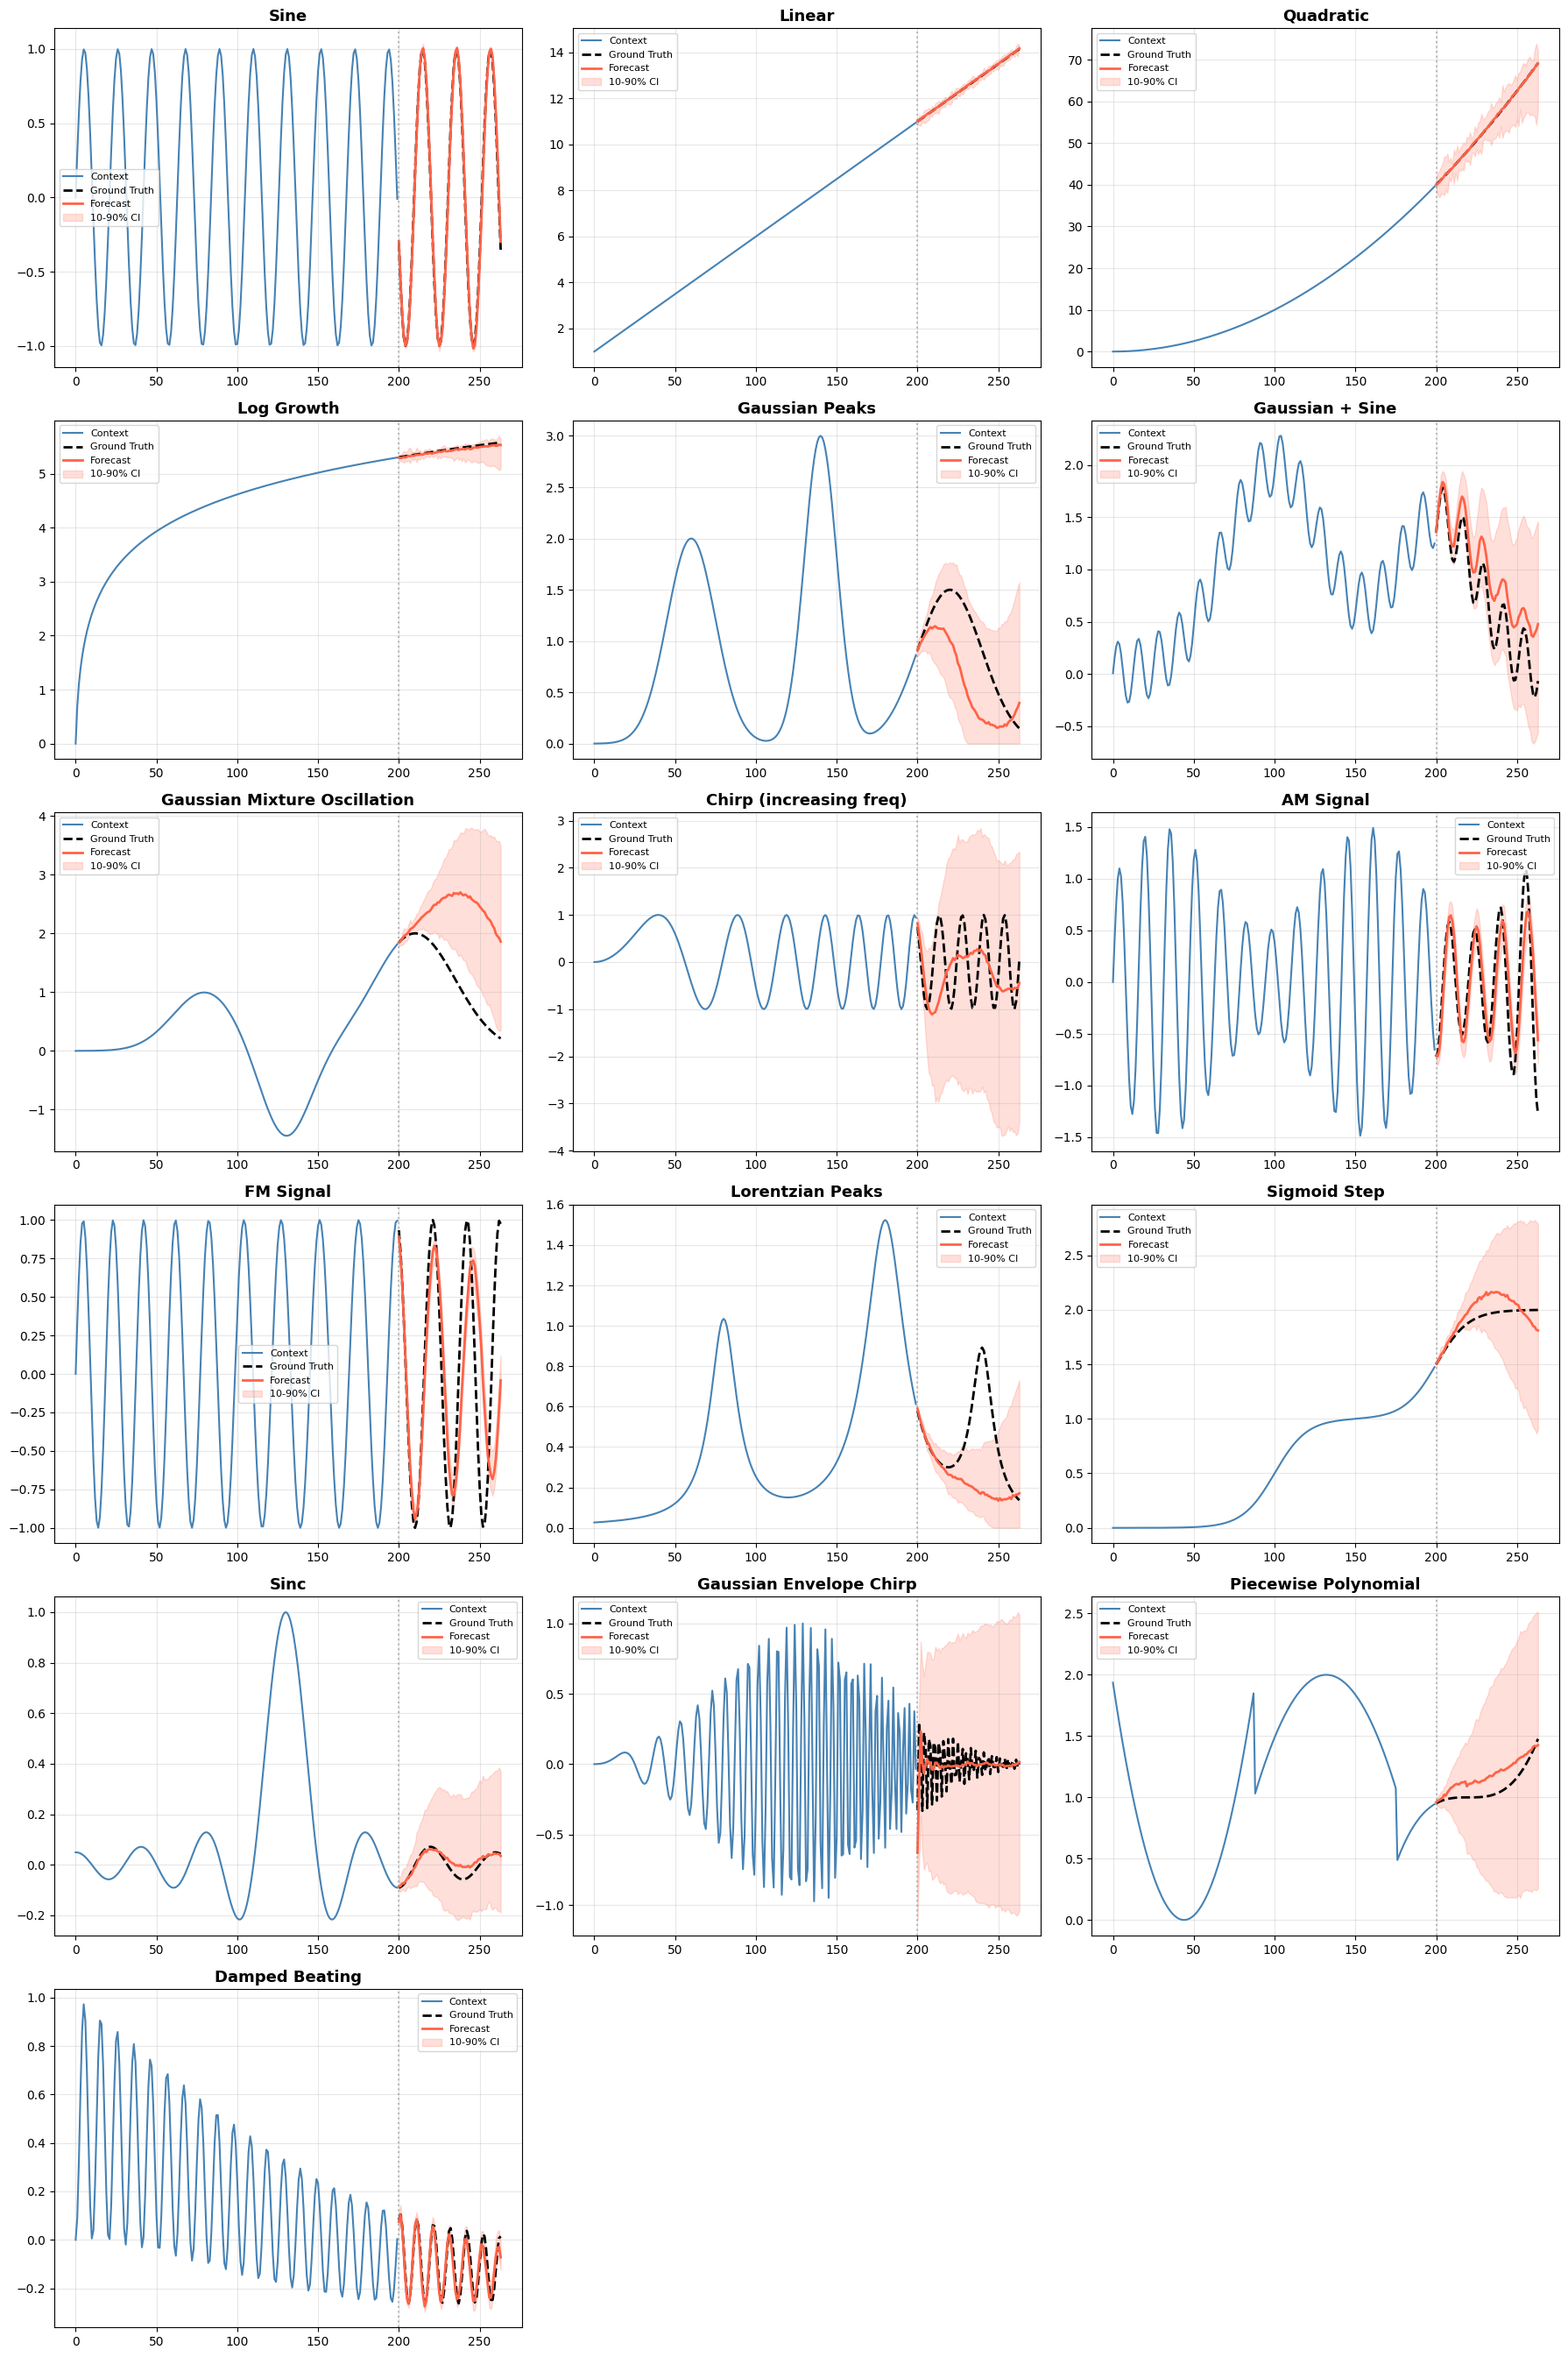

In [48]:
# Plot each function: context, ground truth, and forecast with uncertainty bands
n = len(names)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
axes = axes.flatten()

t_context = np.arange(CONTEXT_LEN)
t_horizon = np.arange(CONTEXT_LEN, CONTEXT_LEN + HORIZON)

for i, name in enumerate(names):
    ax = axes[i]
    gt = series_data[name]["ground_truth"]
    ctx = series_data[name]["context"]
    pred = point_forecast[i]
    quants = quantile_forecast[i]

    ax.plot(t_context, ctx, color="steelblue", label="Context")
    ax.plot(t_horizon, gt, color="black", linestyle="--", linewidth=2, label="Ground Truth")
    ax.plot(t_horizon, pred, color="tomato", linewidth=2, label="Forecast")

    if quants.shape[1] >= 2:
        ax.fill_between(
            t_horizon, quants[:, 1], quants[:, -1],
            alpha=0.2, color="tomato", label="10-90% CI",
        )

    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.axvline(x=CONTEXT_LEN, color="gray", linestyle=":", alpha=0.5)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [49]:
# Per-function MAE summary
print(f"{'Function':<22} {'MAE':>10}")
print("-" * 34)
for i, name in enumerate(names):
    gt = series_data[name]["ground_truth"]
    pred = point_forecast[i]
    mae = np.mean(np.abs(gt - pred))
    print(f"{name:<22} {mae:10.4f}")

Function                      MAE
----------------------------------
Sine                       0.0280
Linear                     0.0141
Quadratic                  0.1030
Log Growth                 0.0253
Gaussian Peaks             0.3986
Gaussian + Sine            0.2766
Gaussian Mixture Oscillation     1.0926
Chirp (increasing freq)     0.6668
AM Signal                  0.2482
FM Signal                  0.3887
Lorentzian Peaks           0.1907
Sigmoid Step               0.1023
Sinc                       0.0172
Gaussian Envelope Chirp     0.1053
Piecewise Polynomial       0.1074
Damped Beating             0.0296


# Financial Data Forecasting\n\nPulling real stock data via `yfinance` and forecasting closing prices.

In [50]:
import yfinance as yf

tickers = ["AAPL", "GOOGL", "MSFT", "AMZN", "TSLA", "SPY"]
STOCK_HORIZON = 30  # forecast 30 trading days ahead

stock_data = {}
for ticker in tickers:
    df = yf.download(ticker, period="2y", auto_adjust=True)
    close = df["Close"].dropna().values.flatten()
    stock_data[ticker] = {
        "context": close[:-STOCK_HORIZON],
        "ground_truth": close[-STOCK_HORIZON:],
        "dates_context": df.index[:-STOCK_HORIZON],
        "dates_horizon": df.index[-STOCK_HORIZON:],
    }
    print(f"{ticker}: {len(close)} days total, context={len(close)-STOCK_HORIZON}, horizon={STOCK_HORIZON}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


AAPL: 501 days total, context=471, horizon=30
GOOGL: 501 days total, context=471, horizon=30


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


MSFT: 501 days total, context=471, horizon=30
AMZN: 501 days total, context=471, horizon=30


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

TSLA: 501 days total, context=471, horizon=30
SPY: 501 days total, context=471, horizon=30


In [51]:
# Forecast stocks
stock_contexts = [stock_data[t]["context"] for t in tickers]

stock_point, stock_quantile = model.forecast(
    horizon=STOCK_HORIZON,
    inputs=stock_contexts,
)
print(f"Stock point forecast shape: {stock_point.shape}")
print(f"Stock quantile forecast shape: {stock_quantile.shape}")

Stock point forecast shape: (6, 30)
Stock quantile forecast shape: (6, 30, 10)


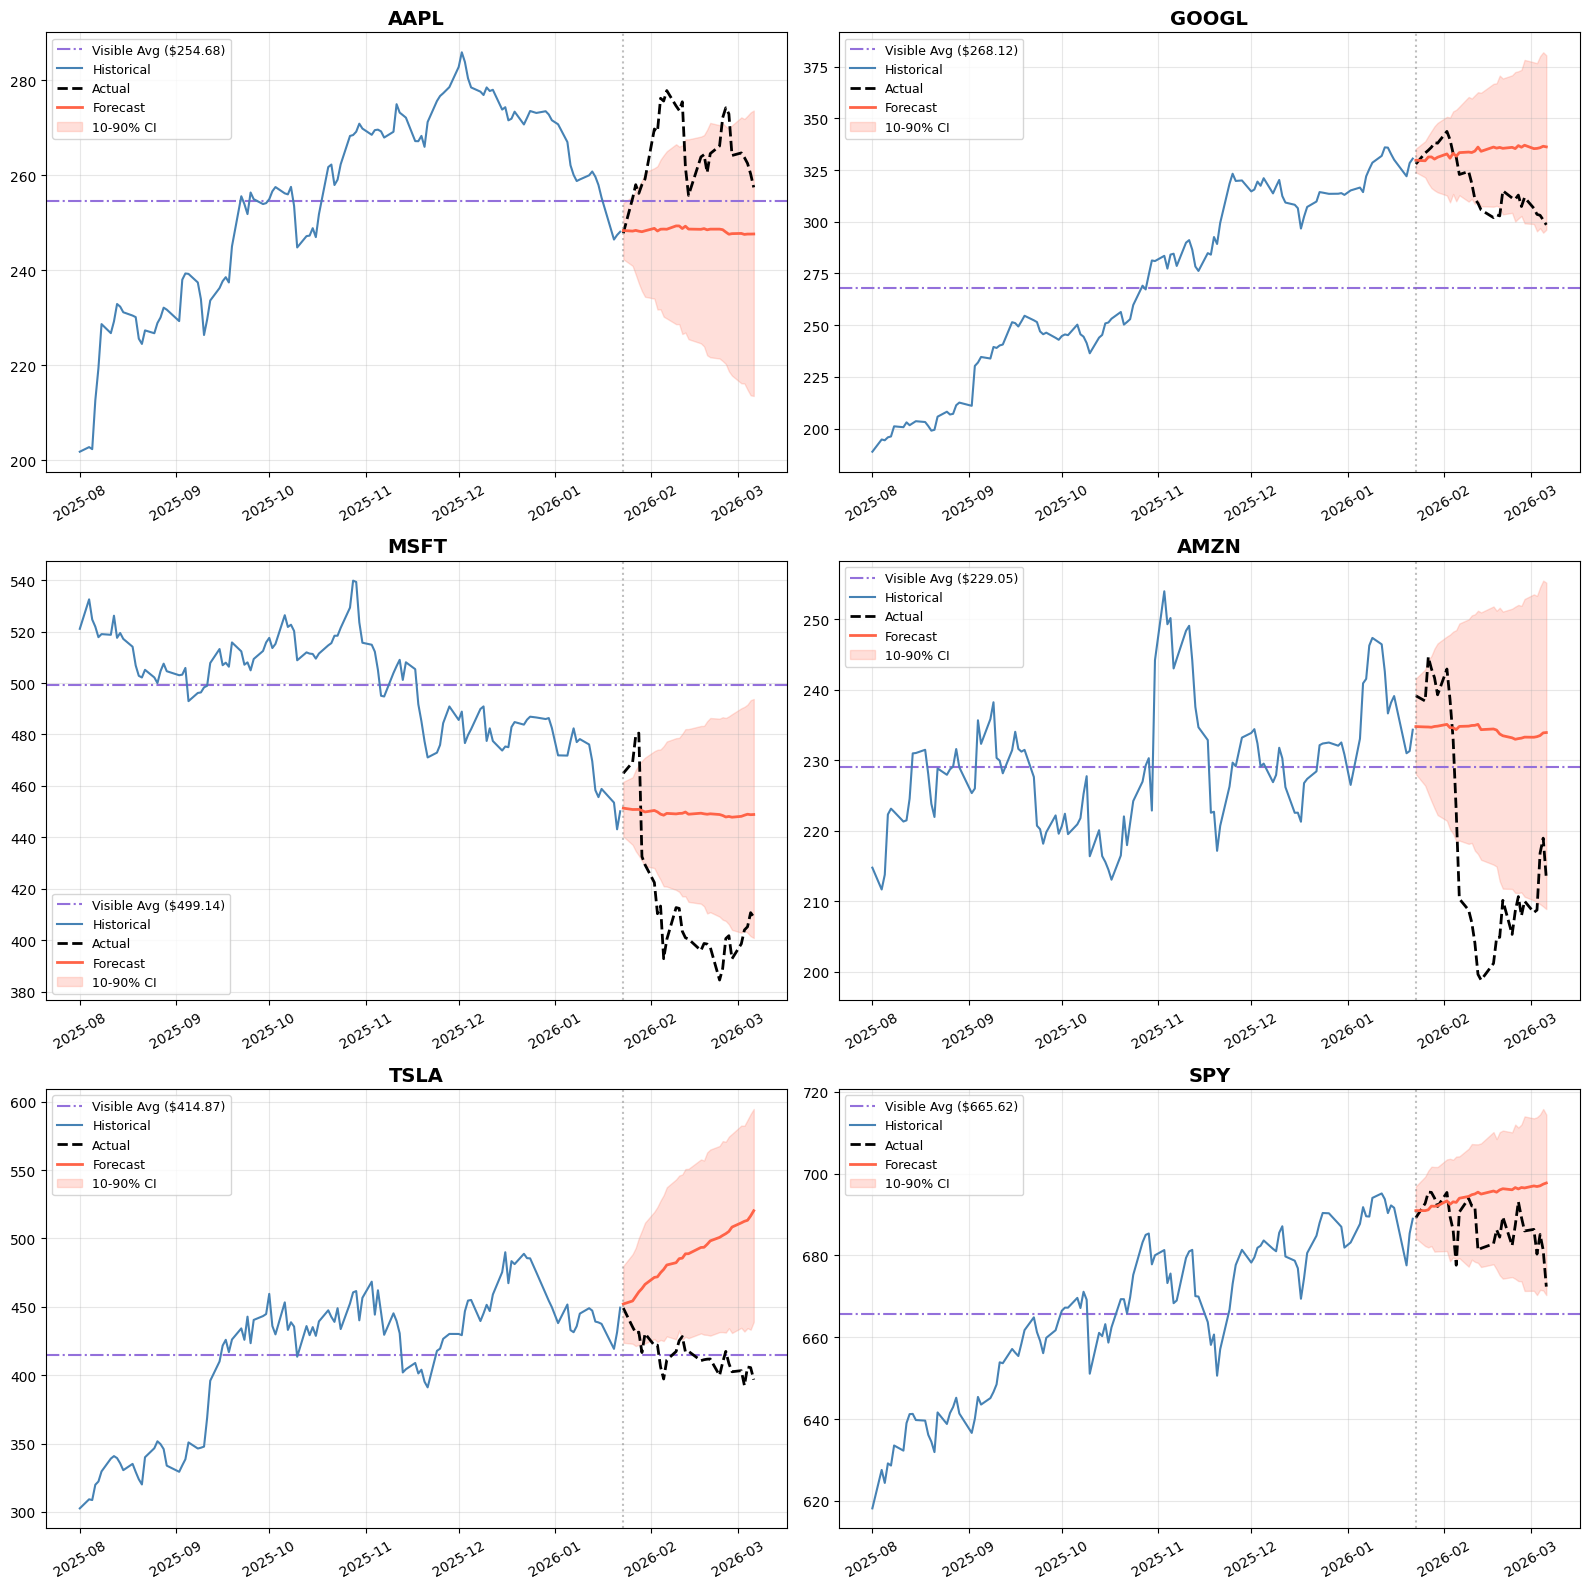

In [52]:
# Plot stock forecasts
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

# Show last 120 context days for readability
TAIL = 120

for i, ticker in enumerate(tickers):
    ax = axes[i]
    d = stock_data[ticker]
    ctx = d["context"]
    gt = d["ground_truth"]
    dates_ctx = d["dates_context"]
    dates_hz = d["dates_horizon"]
    pred = stock_point[i]
    quants = stock_quantile[i]

    # Average over the visible context window only
    ctx_tail = ctx[-TAIL:]
    ctx_mean = np.mean(ctx_tail)
    ax.axhline(y=ctx_mean, color="mediumpurple", linestyle="-.", linewidth=1.5,
               label=f"Visible Avg (${ctx_mean:.2f})")

    # Context tail
    ax.plot(dates_ctx[-TAIL:], ctx_tail, color="steelblue", label="Historical")
    # Ground truth
    ax.plot(dates_hz, gt, color="black", linestyle="--", linewidth=2, label="Actual")
    # Forecast
    ax.plot(dates_hz, pred, color="tomato", linewidth=2, label="Forecast")

    # Confidence interval
    if quants.shape[1] >= 2:
        ax.fill_between(
            dates_hz,
            quants[:, 1],
            quants[:, -1],
            alpha=0.2,
            color="tomato",
            label="10-90% CI",
        )

    ax.axvline(x=dates_hz[0], color="gray", linestyle=":", alpha=0.5)
    ax.set_title(f"{ticker}", fontsize=14, fontweight="bold")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [53]:
# Stock forecast MAE and MAPE summary
print(f"{'Ticker':<10} {'MAE ($)':>10} {'MAPE (%)':>10}")
print("-" * 32)
for i, ticker in enumerate(tickers):
    gt = stock_data[ticker]["ground_truth"]
    pred = stock_point[i]
    mae = np.mean(np.abs(gt - pred))
    mape = np.mean(np.abs((gt - pred) / gt)) * 100
    print(f"{ticker:<10} {mae:10.2f} {mape:10.2f}")

Ticker        MAE ($)   MAPE (%)
--------------------------------
AAPL            16.87       6.28
GOOGL           19.19       6.20
MSFT            41.62      10.25
AMZN            19.45       9.28
TSLA            73.05      17.83
SPY              8.09       1.18
